In [1]:
# 导入数据处理、数值计算和绘图工具。
# Import libraries for data processing, numerical work, and plotting.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 读取前面 notebook 生成的最终建模数据表。
# Read the final modelling table produced by the previous notebooks.
df = pd.read_parquet("../data/curated/master_modelling_table.parquet")

# 只保留适合建模/排名分析的记录。
# Keep only records that passed the modelling-readiness checks.
if "is_modelling_ready" in df.columns:
    df = df[df["is_modelling_ready"] == True].copy()

# 查看筛选后的数据规模，并预览前 5 行。
# Check the filtered data shape and preview the first five rows.
print(df.shape)
df.head()


/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


(11943, 83)


,listing_id,suburb,postcode,lat,lon,weekly_rent,bond,available_date,date_listed,days_listed,...,income_skew_ratio,income_reliable,population_density_2026,is_modelling_ready,n_schools,n_primary_schools,n_secondary_schools,n_government_schools,n_stations,n_stations_both_networks
0,16782629,SOUTH KINGSVILLE,3015,-37.830982,144.87091,460.0,1994.0,"Tuesday, 02 September 2025",2025-08-13,27.0,...,1.203772,True,2299.934248,True,5,5,0,3,3,0
1,17471867,SOUTH KINGSVILLE,3015,-37.826218,144.86755,400.0,1738.0,"Thursday, 27 March 2025",2025-03-06,187.0,...,1.203772,True,2299.934248,True,5,5,0,3,3,0
2,17721851,SOUTH KINGSVILLE,3015,-37.831226,144.86632,795.0,3454.0,"Monday, 15 September 2025",2025-08-19,21.0,...,1.234966,True,1029.407548,True,5,4,1,1,0,0
3,17725855,SOUTH KINGSVILLE,3015,-37.827423,144.86768,675.0,2933.0,"Wednesday, 20 August 2025",2025-08-21,19.0,...,1.203772,True,2299.934248,True,5,5,0,3,3,0
4,17745057,SOUTH KINGSVILLE,3015,-37.826270,144.86790,450.0,1955.0,"Tuesday, 02 September 2025",2025-09-03,6.0,...,1.203772,True,2299.934248,True,5,5,0,3,3,0


In [2]:
# 将 listing-level 数据汇总成 suburb-level 数据，每个 suburb 一行。
# Aggregate listing-level records into one row per suburb.
# 大部分指标使用 median，因为少数豪宅或极端地理位置会明显影响 mean。
# Most metrics use the median because luxury listings or unusual locations can strongly affect the mean.
suburb_summary = (
    df.groupby("suburb")
    .agg(
        # 每个 suburb 的房源数量。
        # Number of rental listings available in each suburb.
        listing_count=("listing_id", "count"),

        # 典型周租金水平。median 是后面 affordability score 的主要输入。
        # Typical weekly rent level. The median is the main affordability input.
        # mean 保留作参考，因为它更容易受到极端高租金影响。
        # The mean is kept as a reference because it is more sensitive to outliers.
        median_weekly_rent=("weekly_rent", "median"),
        mean_weekly_rent=("weekly_rent", "mean"),

        # 典型房屋规模，用中位数代表该 suburb 的常见卧室/浴室数量。
        # Typical property size, represented by median bedrooms and bathrooms.
        median_bedrooms=("bedrooms", "median"),
        median_bathrooms=("bathrooms", "median"),

        # SA2 层面的收入、人口和增长指标，用于 affordability 和 growth scoring。
        # SA2-level income, population, and growth indicators for affordability and growth scoring.
        income_median=("income_median", "median"),
        income_growth_5y=("income_growth_5y", "median"),
        population_growth_5y=("population_growth_5y", "median"),
        population_growth_10y=("population_growth_10y", "median"),
        demand_supply_gap_10y=("demand_supply_gap_10y", "median"),
        population_density_2026=("population_density_2026", "median"),

        # 房源层面的可达性指标。距离越小，通常代表生活便利性越好。
        # Property-level accessibility measures. Lower distances generally imply better access.
        route_km_to_cbd=("route_km_to_cbd", "median"),
        est_route_km_to_nearest_station=("est_route_km_to_nearest_station", "median"),
        straight_km_to_nearest_school=("straight_km_to_nearest_school", "median"),
        straight_km_to_nearest_park=("straight_km_to_nearest_park", "median"),
        straight_km_to_nearest_mall=("straight_km_to_nearest_mall", "median"),

        # 典型房源周边的设施数量。数量越多，通常代表 liveability 越强。
        # Amenity counts around a typical listing. Higher counts usually indicate stronger liveability.
        n_stations_within_1km=("n_stations_within_1km", "median"),
        n_schools_within_1km=("n_schools_within_1km", "median"),
        n_parks_within_500m=("n_parks_within_500m", "median"),
    )
    .reset_index()
)

# 删除房源数量太少的 suburb，避免排名被少数几套房源主导。
# Remove suburbs with too few listings so rankings are not driven by a handful of properties.
suburb_summary = suburb_summary[suburb_summary["listing_count"] >= 20].copy()

# 查看 suburb-level 汇总表的规模，并预览前 5 行。
# Check the suburb-level summary shape and preview the first five rows.
print(suburb_summary.shape)
suburb_summary.head()


(173, 20)


,suburb,listing_count,median_weekly_rent,mean_weekly_rent,median_bedrooms,median_bathrooms,income_median,income_growth_5y,population_growth_5y,population_growth_10y,demand_supply_gap_10y,population_density_2026,route_km_to_cbd,est_route_km_to_nearest_station,straight_km_to_nearest_school,straight_km_to_nearest_park,straight_km_to_nearest_mall,n_stations_within_1km,n_schools_within_1km,n_parks_within_500m
0,ABBOTSFORD,33,650.0,694.393939,2.0,1.0,75322.0,0.223157,0.091298,0.188056,0.000000,6225.083158,5.773650,1.026138,0.474689,0.154090,0.407300,2.0,5.0,5.0
2,AIRPORT WEST,26,560.0,593.269231,3.0,1.0,68085.0,0.205642,0.076867,0.146669,0.000000,2378.118743,20.423955,5.471743,0.578236,0.187936,0.953020,0.0,2.0,4.0
9,ALPHINGTON,29,550.0,587.413793,2.0,1.0,81513.0,0.178939,0.203254,0.352992,0.000000,2454.985503,10.625510,1.191588,0.538570,0.096252,2.193110,2.0,3.0,4.0
11,ALTONA MEADOWS,37,520.0,508.108108,3.0,1.0,61570.0,0.182833,0.002954,0.011014,-0.005380,1765.338912,24.174770,2.249753,0.578249,0.213106,0.977682,0.0,1.0,2.0
12,ALTONA NORTH,35,675.0,702.714286,3.0,2.0,66099.0,0.207067,0.156874,0.313173,-0.007295,1029.407548,13.187260,4.228409,0.809327,0.223492,1.041774,0.0,2.0,2.0


In [3]:
# 定义 min-max 标准化函数，把不同单位的变量统一缩放到 0 到 1。
# Define a min-max scaling helper to convert variables with different units onto a 0-to-1 scale.
def minmax_score(series, higher_is_better=True):
    # 转成 float，确保后续数值计算稳定。
    # Convert to float so the numeric operations are consistent.
    series = series.astype(float)
    min_val = series.min()
    max_val = series.max()

    # 如果所有值都一样，就给中性分数 0.5，避免除以 0。
    # If all values are identical, assign a neutral score of 0.5 to avoid division by zero.
    if max_val == min_val:
        score = pd.Series(0.5, index=series.index)
    else:
        score = (series - min_val) / (max_val - min_val)

    # 对距离、租金压力这类“越小越好”的指标，把分数反转。
    # For metrics where lower is better, such as distance or rent pressure, invert the score.
    if not higher_is_better:
        score = 1 - score

    return score


In [4]:
# 计算租金收入比：年租金除以当地 median income。
# Calculate rent-to-income ratio: annual rent divided by local median income.
suburb_summary["rent_to_income_ratio"] = (
    suburb_summary["median_weekly_rent"] * 52
    / suburb_summary["income_median"]
)

# affordability score 越高，表示租金相对收入越低，越负担得起。
# A higher affordability score means rent is lower relative to income.
suburb_summary["affordability_score"] = minmax_score(
    suburb_summary["rent_to_income_ratio"],
    higher_is_better=False
)

# 选出 affordability score 最高的 10 个 suburb。
# Select the top 10 suburbs with the highest affordability score.
affordable_top10 = (
    suburb_summary
    .sort_values("affordability_score", ascending=False)
    .head(10)
)

# 展示 affordability ranking 需要的关键字段。
# Display the key columns used to interpret the affordability ranking.
affordable_top10[[
    "suburb",
    "listing_count",
    "median_weekly_rent",
    "income_median",
    "rent_to_income_ratio",
    "affordability_score"
]]


,suburb,listing_count,median_weekly_rent,income_median,rent_to_income_ratio,affordability_score
271,HIGHTON,26,350.0,59667.0,0.305026,1.000000
9,ALPHINGTON,29,550.0,81513.0,0.350864,0.937469
605,WEST FOOTSCRAY,37,470.0,66706.0,0.366384,0.916298
615,WINDSOR,26,550.0,76813.0,0.372333,0.908183
226,GEELONG WEST,25,470.0,64962.0,0.376220,0.902880
604,WERRIBEE,197,460.0,62584.0,0.382206,0.894714
379,MOONEE PONDS,50,557.5,73817.0,0.392728,0.880360
591,WALLAN,55,460.0,60634.0,0.394498,0.877946
603,WENDOUREE,35,400.0,52596.0,0.395467,0.876624
632,YARRAVILLE,31,620.0,81233.0,0.396883,0.874692


In [ ]:
# 构建增长潜力分数。
# Build the rental growth-potential score.
# 权重含义：人口增长 40%，收入增长 30%，供需缺口 30%。
#by papers. 验证 会问
# Weights: 40% population growth, 30% income growth, and 30% demand-supply gap.
suburb_summary["growth_score"] = (
    0.40 * minmax_score(suburb_summary["population_growth_5y"], higher_is_better=True)
    + 0.30 * minmax_score(suburb_summary["income_growth_5y"], higher_is_better=True)
    + 0.30 * minmax_score(suburb_summary["demand_supply_gap_10y"], higher_is_better=True)
)

# 选出 growth score 最高的 10 个 suburb。
# Select the top 10 suburbs with the highest growth-potential score.
growth_top10 = (
    suburb_summary
    .sort_values("growth_score", ascending=False)
    .head(10)
)

# 展示增长潜力排名及其组成指标。
# Display the growth ranking and its component indicators.
growth_top10[[
    "suburb",
    "listing_count",
    "median_weekly_rent",
    "population_growth_5y",
    "income_growth_5y",
    "demand_supply_gap_10y",
    "growth_score"
]]


,suburb,listing_count,median_weekly_rent,population_growth_5y,income_growth_5y,demand_supply_gap_10y,growth_score
591,WALLAN,55,460.0,0.585843,0.148611,0.000000,0.539861
56,BEVERIDGE,51,490.0,0.585843,0.148611,0.000000,0.539861
183,DONNYBROOK,83,500.0,0.496439,0.194953,0.000000,0.500419
625,WYNDHAM VALE,119,455.0,0.481854,0.214977,0.000000,0.499878
360,MELBOURNE,293,660.0,0.112326,0.694685,0.000000,0.473103
139,CLYDE,60,592.5,0.465453,0.174440,0.000000,0.469457
488,ROCKBANK,52,490.0,0.533380,0.197142,-0.022584,0.428757
555,TARNEIT,298,530.0,0.443408,0.120013,0.000000,0.428596
571,TORQUAY,31,710.0,0.088697,0.174150,0.046517,0.412729
186,DOVETON,20,520.0,0.068287,0.160423,0.043068,0.377258


In [6]:
# 构建宜居性分数。
# Build the liveability score.
# 距离类指标越小越好，设施数量类指标越大越好。
# Distance metrics are better when lower; amenity-count metrics are better when higher.
suburb_summary["liveability_score"] = (
    # 到车站、学校、公园、商场更近，会提高 liveability score。
    # Shorter distances to stations, schools, parks, and malls increase the liveability score.
    0.25 * minmax_score(suburb_summary["est_route_km_to_nearest_station"], higher_is_better=False)
    + 0.20 * minmax_score(suburb_summary["straight_km_to_nearest_school"], higher_is_better=False)
    + 0.20 * minmax_score(suburb_summary["straight_km_to_nearest_park"], higher_is_better=False)
    + 0.15 * minmax_score(suburb_summary["straight_km_to_nearest_mall"], higher_is_better=False)
    # 附近学校和公园越多，也会提高 liveability score。
    # More nearby schools and parks also increase the liveability score.
    + 0.10 * minmax_score(suburb_summary["n_schools_within_1km"], higher_is_better=True)
    + 0.10 * minmax_score(suburb_summary["n_parks_within_500m"], higher_is_better=True)
)

# 选出 liveability score 最高的 10 个 suburb。
# Select the top 10 suburbs with the highest liveability score.
liveable_top10 = (
    suburb_summary
    .sort_values("liveability_score", ascending=False)
    .head(10)
)

# 展示宜居性排名及关键可达性指标。
# Display the liveability ranking and key accessibility indicators.
liveable_top10[[
    "suburb",
    "listing_count",
    "est_route_km_to_nearest_station",
    "straight_km_to_nearest_school",
    "straight_km_to_nearest_park",
    "straight_km_to_nearest_mall",
    "liveability_score"
]]


,suburb,listing_count,est_route_km_to_nearest_station,straight_km_to_nearest_school,straight_km_to_nearest_park,straight_km_to_nearest_mall,liveability_score
215,FITZROY NORTH,30,1.706090,0.323500,0.151493,1.610418,0.895682
216,FLEMINGTON,30,0.930117,0.306638,0.173771,0.584695,0.877511
147,COLLINGWOOD,30,1.067888,0.323942,0.144323,1.157643,0.874960
606,WEST MELBOURNE,69,0.742662,0.436077,0.191729,0.646757,0.863636
214,FITZROY,27,1.779681,0.390187,0.197188,1.188136,0.861789
526,SOUTH YARRA,196,0.503137,0.268189,0.200815,0.316970,0.859483
453,PARKVILLE,30,1.083296,0.519433,0.151329,1.225323,0.858839
527,SOUTHBANK,289,1.245884,0.474640,0.133755,0.496679,0.857413
0,ABBOTSFORD,33,1.026138,0.474689,0.154090,0.407300,0.856919
218,FOOTSCRAY,142,0.972828,0.256777,0.142217,0.955609,0.854179


In [7]:
# 构建综合分数：affordability 和 liveability 各占 50%。
# Build a combined score with equal weight on affordability and liveability.
suburb_summary["affordable_liveable_score"] = (
    0.5 * suburb_summary["affordability_score"]
    + 0.5 * suburb_summary["liveability_score"]
)

# 选出既相对便宜又相对宜居的前 10 个 suburb。
# Select the top 10 suburbs that balance affordability and liveability.
affordable_liveable_top10 = (
    suburb_summary
    .sort_values("affordable_liveable_score", ascending=False)
    .head(10)
)

# 展示综合排名及解释这个排名需要的核心字段。
# Display the combined ranking and the core fields needed to interpret it.
affordable_liveable_top10[[
    "suburb",
    "listing_count",
    "median_weekly_rent",
    "rent_to_income_ratio",
    "liveability_score",
    "affordable_liveable_score"
]]


,suburb,listing_count,median_weekly_rent,rent_to_income_ratio,liveability_score,affordable_liveable_score
615,WINDSOR,26,550.0,0.372333,0.848460,0.878321
9,ALPHINGTON,29,550.0,0.350864,0.798516,0.867993
147,COLLINGWOOD,30,645.0,0.423324,0.874960,0.856791
216,FLEMINGTON,30,510.0,0.433178,0.877511,0.851346
264,HEIDELBERG,27,560.0,0.408644,0.820595,0.839621
471,PRAHRAN,77,630.0,0.426490,0.839102,0.836702
605,WEST FOOTSCRAY,37,470.0,0.366384,0.746291,0.831294
0,ABBOTSFORD,33,650.0,0.448740,0.856919,0.830435
481,RICHMOND,99,730.0,0.442806,0.831876,0.821961
604,WERRIBEE,197,460.0,0.382206,0.747986,0.821350


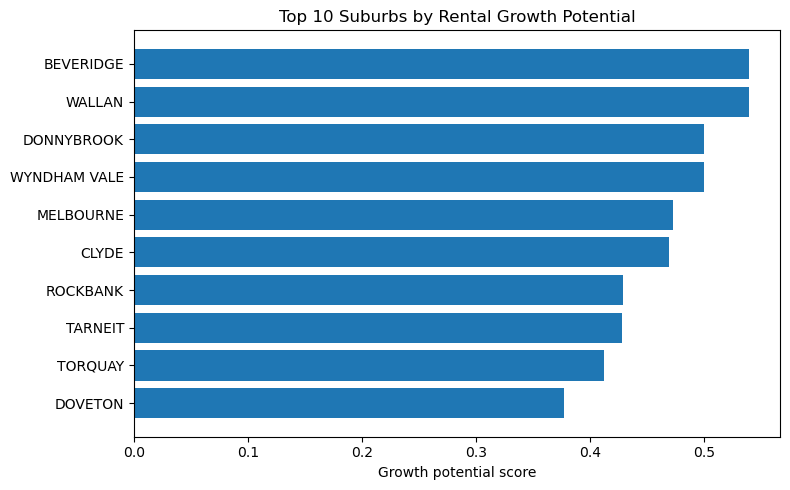

In [8]:
# 为横向柱状图排序：分数低的在下方，高的在上方，图形更容易阅读。
# Sort for a horizontal bar chart so lower scores appear lower and higher scores appear higher.
plot_df = growth_top10.sort_values("growth_score")

# 绘制增长潜力 Top 10 suburb 的柱状图。
# Plot the top 10 suburbs by rental growth-potential score.
plt.figure(figsize=(8, 5))
plt.barh(plot_df["suburb"], plot_df["growth_score"])
plt.xlabel("Growth potential score")
plt.title("Top 10 Suburbs by Rental Growth Potential")
plt.tight_layout()
plt.show()


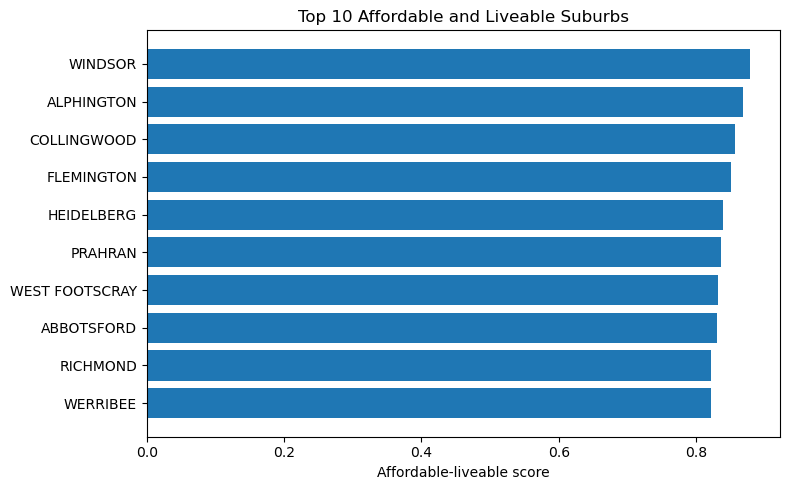

In [9]:
# 为横向柱状图排序，便于比较综合分数。
# Sort for a horizontal bar chart to make the combined scores easier to compare.
plot_df = affordable_liveable_top10.sort_values("affordable_liveable_score")

# 绘制兼顾 affordability 和 liveability 的 Top 10 suburb。
# Plot the top 10 suburbs that balance affordability and liveability.
plt.figure(figsize=(8, 5))
plt.barh(plot_df["suburb"], plot_df["affordable_liveable_score"])
plt.xlabel("Affordable-liveable score")
plt.title("Top 10 Affordable and Liveable Suburbs")
plt.tight_layout()
plt.show()
